In [1]:
import sys

import torch

import pandas as pd

import pm4py
from pm4py.visualization.petri_net import visualizer as pn_vis

from config.feature_config import FeatureConfig
from config.ga_config import GAConfig

from utils.general_utils import set_stdout_to_file, set_seed
from utils.feature_utils import df_to_sequence_array

from model.preprocessor import PreprocessorArtifacts

from model.next_event_model import ProcessLSTM
from model.model_wrapper import ModelWrapper

from ga_search.search import CounterfactualGA

from process.engine import ProcessModelConstraintEngine
from process.experimenter import ExperimentHandler

### --- Load Dataset & Models ---

In [2]:
set_seed(seed=42)

In [3]:
df = pd.read_excel(
    "../../data/bpic12.xlsx",
    engine="openpyxl",
    keep_default_na=False,
    dtype={
        "case:concept:name": "string",
        "concept:name": "string",
        "lifecycle:transition": "string",
        "org:resource": "string",
        "case:REG_DATE_HR": "string",
        "case:REG_DATE_DAY": "string",
        "case:REG_DATE_MON": "string",
        "case:AMOUNT_REQ": "float32",
        "time_delta": "float32",
    }
)

df["time:timestamp"] = pd.to_datetime(df["time:timestamp"])

In [4]:
df.head(20)

,case:concept:name,time:timestamp,case:AMOUNT_REQ,case:REG_DATE_DAY,case:REG_DATE_HR,case:REG_DATE_MON,concept:name,lifecycle:transition,org:resource,time_delta
0,173688,2011-10-01 00:38:44.546,20000.0,Saturday,12 AM,October,A_SUBMITTED,COMPLETE,112,0.000000
1,173688,2011-10-01 00:38:44.880,20000.0,Saturday,12 AM,October,A_PARTLYSUBMITTED,COMPLETE,112,0.334000
2,173688,2011-10-01 00:39:37.906,20000.0,Saturday,12 AM,October,A_PREACCEPTED,COMPLETE,112,53.026001
3,173688,2011-10-01 11:42:43.308,20000.0,Saturday,12 AM,October,A_ACCEPTED,COMPLETE,10862,39785.402344
4,173688,2011-10-01 11:45:09.243,20000.0,Saturday,12 AM,October,O_SELECTED,COMPLETE,10862,145.934998
5,173688,2011-10-01 11:45:09.243,20000.0,Saturday,12 AM,October,A_FINALIZED,COMPLETE,10862,0.000000
6,173688,2011-10-01 11:45:11.197,20000.0,Saturday,12 AM,October,O_CREATED,COMPLETE,10862,1.954000
7,173688,2011-10-01 11:45:11.380,20000.0,Saturday,12 AM,October,O_SENT,COMPLETE,10862,0.183000
8,173688,2011-10-10 11:33:03.668,20000.0,Saturday,12 AM,October,O_SENT_BACK,COMPLETE,11049,776872.312500
9,173688,2011-10-13 10:37:29.226,20000.0,Saturday,12 AM,October,A_REGISTERED,COMPLETE,10629,255865.562500


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [6]:
feature_config = FeatureConfig.load()

In [7]:
feature_config.summary()

  activity_feature:    concept:name
  feature_order:       ['case:AMOUNT_REQ', 'case:REG_DATE_DAY', 'case:REG_DATE_HR', 'case:REG_DATE_MON', 'concept:name', 'lifecycle:transition', 'org:resource', 'time_delta']
--------------------------------------------------------------------------------------------------------------------------------------
Feature                        Type           Level    Vary   Range/Categories                         MAD        Source              
--------------------------------------------------------------------------------------------------------------------------------------
time_delta                     continuous     event    yes    [0.00, 1315.95]                          0.4980     quantile_derived    
case:AMOUNT_REQ                continuous     case     yes    [3000.00, 40000.00]                      5000.0000  quantile_derived    
case:REG_DATE_DAY              categorical    case     yes    ['Friday', 'Monday', 'Saturday', ...]    N/A        

In [8]:
preprocessor_artifacts = PreprocessorArtifacts.load()

In [9]:
model = ProcessLSTM.load()

In [10]:
model_wrapper = ModelWrapper(
    model=model,
    preprocessor_artifacts=preprocessor_artifacts,
    device=device
)

### --- Process Constraints ---

In [11]:
net, initial_marking, final_marking = pm4py.discover_petri_net_inductive(
    df,
    noise_threshold=0.5,
    case_id_key='case:concept:name',  
    activity_key='concept:name',
    timestamp_key='time:timestamp'
)

engine = ProcessModelConstraintEngine(
    petri_net=net,
    initial_marking=initial_marking,
    final_marking=final_marking
)
engine.save()

In [12]:
# engine = ProcessModelConstraintEngine.load()

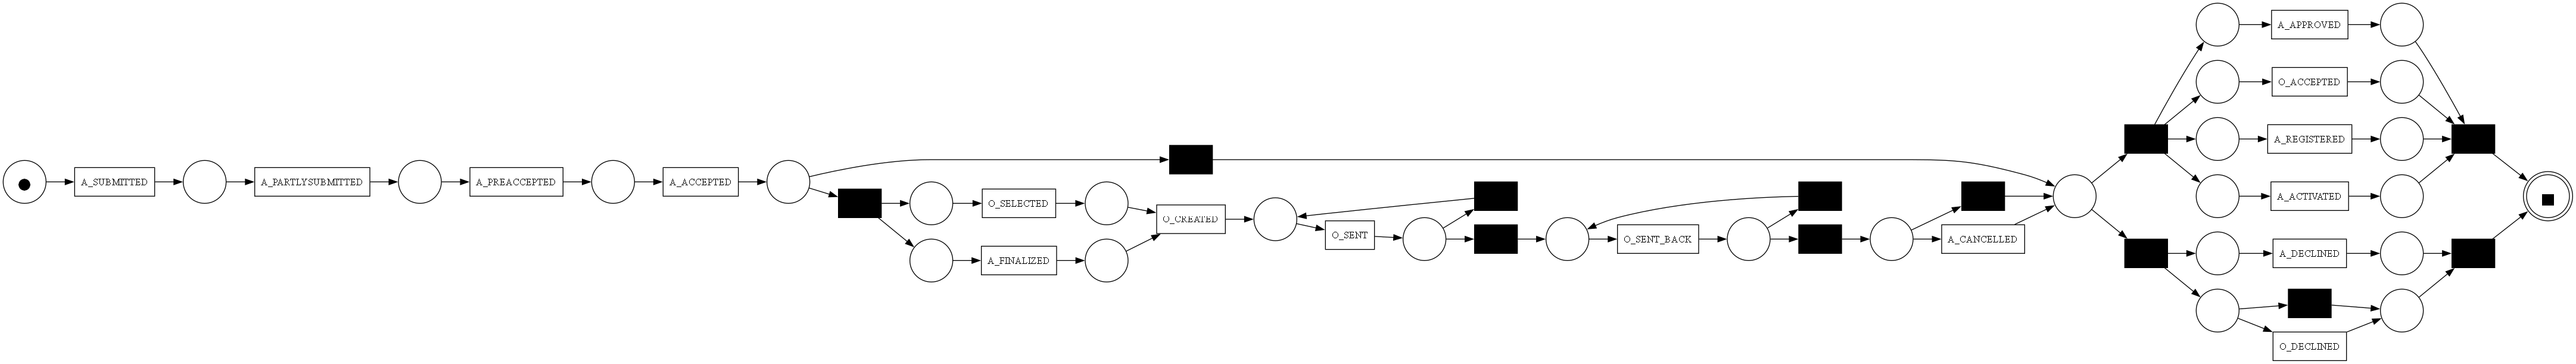

In [13]:
gviz = pn_vis.apply(
    net,
    initial_marking,
    final_marking,
)

pn_vis.view(gviz)

In [14]:
engine.parallel_sets

[{'A_FINALIZED', 'O_SELECTED'},
 {'A_DECLINED', 'O_DECLINED'},
 {'A_ACTIVATED', 'A_APPROVED', 'A_REGISTERED', 'O_ACCEPTED'}]

In [15]:
engine.branching_sets

[{'A_CANCELLED',
  'A_FINALIZED',
  'O_CREATED',
  'O_SELECTED',
  'O_SENT',
  'O_SENT_BACK'},
 {'A_ACTIVATED',
  'A_APPROVED',
  'A_DECLINED',
  'A_REGISTERED',
  'O_ACCEPTED',
  'O_DECLINED'}]

### --- Experiments Generation ---

In [16]:
log_file, original_stdout = set_stdout_to_file(filepath="logs/bpic12-cf_generated_experiments_ga_output.txt", console=False)

In [17]:
generator = ExperimentHandler(
    constraint_engine=engine,
)

In [18]:
exp_df_sin = generator.generate_experiments_from_log(
    df=df,
    case_id_field="case:concept:name",
    activity_field="concept:name",
    sort_field="time:timestamp",
    save_path="experiments/cf_generated_experiments_single_desired",
    min_desired=1,
    max_desired=1,
)

In [19]:
exp_df_mul = generator.generate_experiments_from_log(
    df=df,
    case_id_field="case:concept:name",
    activity_field="concept:name",
    sort_field="time:timestamp",
    save_path="experiments/cf_generated_experiments_multiple_desired",
    min_desired=2,
)

In [20]:
max(exp_df_sin['num_desired'])

1

In [21]:
len(exp_df_sin)

500

In [22]:
exp_df_sin.head()

,template_id,case:concept:name,trace_length,start_pos,length,num_desired,source_pattern,target_pattern,desired_positions,source_support,target_support,num_cases_for_template,experiment_type
0,0,210128,3,0,3,1,"(A_SUBMITTED, A_PARTLYSUBMITTED, A_PREACCEPTED)","(A_SUBMITTED, A_PARTLYSUBMITTED, A_DECLINED)",{2: {'A_DECLINED'}},7367,5719,10,window_variant_mixed
1,0,180968,4,0,3,1,"(A_SUBMITTED, A_PARTLYSUBMITTED, A_PREACCEPTED)","(A_SUBMITTED, A_PARTLYSUBMITTED, A_DECLINED)",{2: {'A_DECLINED'}},7367,5719,10,window_variant_mixed
2,0,208865,5,0,3,1,"(A_SUBMITTED, A_PARTLYSUBMITTED, A_PREACCEPTED)","(A_SUBMITTED, A_PARTLYSUBMITTED, A_DECLINED)",{2: {'A_DECLINED'}},7367,5719,10,window_variant_mixed
3,0,210602,8,0,3,1,"(A_SUBMITTED, A_PARTLYSUBMITTED, A_PREACCEPTED)","(A_SUBMITTED, A_PARTLYSUBMITTED, A_DECLINED)",{2: {'A_DECLINED'}},7367,5719,10,window_variant_mixed
4,0,213456,9,0,3,1,"(A_SUBMITTED, A_PARTLYSUBMITTED, A_PREACCEPTED)","(A_SUBMITTED, A_PARTLYSUBMITTED, A_DECLINED)",{2: {'A_DECLINED'}},7367,5719,10,window_variant_mixed


In [23]:
min(exp_df_mul['num_desired'])

2

In [24]:
max(exp_df_mul['num_desired'])

4

In [25]:
len(exp_df_mul)

500

In [26]:
exp_df_mul.head()

,template_id,case:concept:name,trace_length,start_pos,length,num_desired,source_pattern,target_pattern,desired_positions,source_support,target_support,num_cases_for_template,experiment_type
0,0,177657,13,7,3,2,"(O_SENT, O_SENT_BACK, O_ACCEPTED)","(O_SENT, O_CANCELLED, O_SELECTED)","{8: {'O_CANCELLED'}, 9: {'O_SELECTED'}}",850,659,10,window_variant_mixed
1,0,192659,13,7,3,2,"(O_SENT, O_SENT_BACK, O_ACCEPTED)","(O_SENT, O_CANCELLED, O_SELECTED)","{8: {'O_CANCELLED'}, 9: {'O_SELECTED'}}",850,659,10,window_variant_mixed
2,0,189589,13,7,3,2,"(O_SENT, O_SENT_BACK, O_ACCEPTED)","(O_SENT, O_CANCELLED, O_SELECTED)","{8: {'O_CANCELLED'}, 9: {'O_SELECTED'}}",850,659,10,window_variant_mixed
3,0,191566,13,7,3,2,"(O_SENT, O_SENT_BACK, O_ACCEPTED)","(O_SENT, O_CANCELLED, O_SELECTED)","{8: {'O_CANCELLED'}, 9: {'O_SELECTED'}}",850,659,10,window_variant_mixed
4,0,198735,13,7,3,2,"(O_SENT, O_SENT_BACK, O_ACCEPTED)","(O_SENT, O_CANCELLED, O_SELECTED)","{8: {'O_CANCELLED'}, 9: {'O_SELECTED'}}",850,659,10,window_variant_mixed


In [27]:
# exp_df_sin, metadata_sin = ExperimentHandler.load("experiments/cf_generated_experiments_single_desired")
# print("Mined using parameters:", metadata_sin["parameters"])

# exp_df_mul, metadata_mul = ExperimentHandler.load("experiments/cf_generated_experiments_multiple_desired")
# print("Mined using parameters:", metadata_mul["parameters"])

### --- Counterfactuals ---

In [28]:
ga_config = GAConfig(
    w_distance=1.0,
    w_sparsity=1.0,
    w_margin=1.0,
    w_process_violation=1.0,
)
ga_config.validate()

cf_GA = CounterfactualGA(
    ga_config=ga_config,
    feature_config=feature_config,
    model_wrapper=model_wrapper
)

In [29]:
results_sin = generator.run_experiment_df(
    cf_method=cf_GA,
    technique="GA_single_desired",
    exp_df=exp_df_sin,
    df=df,
    feature_config=feature_config,
    case_id_field="case:concept:name",
    sort_field="time:timestamp",
)

Experiments:   0%|          | 0/500 [00:00<?, ?case/s]

In [30]:
results_sin

,template_id,case:concept:name,trace_length,num_desired,num_flexible,DISTANCE,CONT_DISTANCE,CAT_DISTANCE,SPARSITY,PROCESS_VIOLATION,...,best_cf_fitness,best_cf_process_violation,best_cf_distance,best_cf_cat_distance,best_cf_cont_distance,best_cf_sparsity,best_cf_margin_loss,best_cf_margin_loss_na,best_cf_margin_loss_flipped,best_cf_margin_loss_na_flipped
0,0,210128,3,1,0,0.520624,0.511249,0.530000,0.643750,0.000000,...,0.184116,0.000000,0.059116,0.000000,0.118231,0.125000,0.000000,0.000000,0.0,0.000000
1,1,187256,3,1,0,0.414156,0.198312,0.630000,0.537500,0.000000,...,0.076112,0.000000,0.000000,0.000000,0.000000,0.000000,0.076112,0.076112,0.0,0.000000
2,1,211510,3,1,0,0.483971,0.447942,0.520000,0.587500,0.000000,...,0.217071,0.000000,0.092071,0.000000,0.184141,0.125000,0.000000,0.000000,0.0,0.000000
3,1,184360,3,1,0,0.468954,0.337909,0.600000,0.581250,0.000000,...,0.273989,0.000000,0.148989,0.000000,0.297978,0.125000,0.000000,0.000000,0.0,0.000000
4,1,204757,3,1,0,0.500944,0.481887,0.520000,0.587500,0.000000,...,0.242788,0.000000,0.117788,0.000000,0.235575,0.125000,0.000000,0.000000,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307,49,195482,14,1,2,0.530106,0.423546,0.636667,0.673214,0.064516,...,0.662304,0.064516,0.240645,0.266667,0.214622,0.357143,0.000000,0.739688,0.0,0.999999
308,49,183292,14,1,2,0.639524,0.555715,0.723333,0.785714,0.170968,...,0.794937,0.064516,0.301850,0.333333,0.270366,0.428571,0.000000,0.000000,0.0,0.000000
309,49,196861,14,1,2,0.676695,0.643390,0.710000,0.810714,0.067742,...,1.075470,0.064516,0.439525,0.333333,0.545716,0.571429,0.000000,0.000000,0.0,0.000000
310,49,185452,14,1,2,0.681859,0.600385,0.763333,0.800000,0.064516,...,0.943029,0.064516,0.378513,0.400000,0.357026,0.500000,0.000000,0.000000,0.0,0.000000


In [31]:
results_mul = generator.run_experiment_df(
    cf_method=cf_GA,
    technique="GA_multiple_desired",
    exp_df=exp_df_mul,
    df=df,
    feature_config=feature_config,
    case_id_field="case:concept:name",
    sort_field="time:timestamp",
)

Experiments:   0%|          | 0/500 [00:00<?, ?case/s]

In [32]:
results_mul

,template_id,case:concept:name,trace_length,num_desired,num_flexible,DISTANCE,CONT_DISTANCE,CAT_DISTANCE,SPARSITY,PROCESS_VIOLATION,...,best_cf_fitness,best_cf_process_violation,best_cf_distance,best_cf_cat_distance,best_cf_cont_distance,best_cf_sparsity,best_cf_margin_loss,best_cf_margin_loss_na,best_cf_margin_loss_flipped,best_cf_margin_loss_na_flipped
0,0,177657,13,2,6,0.535487,0.561883,0.509091,0.6150,0.187500,...,0.765105,0.187500,0.277605,0.090909,0.464300,0.30,0.000000,0.453585,0.000000,0.500000
1,0,192659,13,2,6,0.388065,0.326130,0.450000,0.4675,0.187500,...,0.929733,0.187500,0.000000,0.000000,0.000000,0.00,0.742233,0.770871,0.999999,0.999999
2,0,189589,13,2,6,0.523054,0.487018,0.559091,0.6550,0.187500,...,0.739292,0.187500,0.251792,0.181818,0.321766,0.30,0.000000,0.445731,0.000000,0.500000
3,0,191566,13,2,6,0.523585,0.547169,0.500000,0.5925,0.187500,...,0.835178,0.187500,0.297678,0.272727,0.322628,0.35,0.000000,0.424624,0.000000,0.500000
4,0,198735,13,2,6,0.514660,0.520229,0.509091,0.5875,0.240625,...,1.035641,0.187500,0.045455,0.090909,0.000000,0.05,0.752686,0.752686,0.999999,0.999999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
291,48,189055,13,4,6,0.650633,0.587631,0.713636,0.7425,0.052632,...,0.820279,0.052632,0.367647,0.181818,0.553476,0.40,0.000000,0.713051,0.000000,0.750000
292,48,214226,13,4,6,0.645724,0.605084,0.686364,0.7675,0.052632,...,0.820708,0.052632,0.368077,0.181818,0.554335,0.40,0.000000,0.701760,0.000000,0.750000
293,48,205316,13,4,6,0.576277,0.561645,0.590909,0.7525,0.052632,...,0.737776,0.052632,0.235144,0.181818,0.288471,0.45,0.000000,0.553537,0.000000,0.500000
294,49,207434,12,4,2,0.434318,0.377726,0.490909,0.4850,0.083333,...,0.403480,0.138889,0.000000,0.000000,0.000000,0.00,0.264591,0.486295,0.250000,0.500000


### --- Cleanup ---

In [33]:
sys.stdout = original_stdout
log_file.close()